## CREATE AGENT WITH TOOLS

[Tavily Search](https://python.langchain.com/docs/integrations/tools/tavily_search/?_gl=1*45v414*_gcl_au*MzczNTIzNTQ1LjE3NTYyODY3MDA.*_ga*NzgxNDA4NzU1LjE3NTYyODY3MDA.*_ga_47WX3HKKY2*czE3NjAwNjU4OTAkbzQkZzAkdDE3NjAwNjU4OTAkajYwJGwwJGgw)

`pip install -U langchain-tavily`

In [27]:
import os 
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek

load_dotenv("apikey.env")
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = os.getenv("LANGCHAIN_API_KEY")
os.environ['LANGCHAIN_PROJECT'] = "agent with tools"
BASE_URL = 'https://api.deepseek.com'
API_KEY = os.getenv('DEEPSEEK-API-KEY')
TRAVILY_API_KEY = os.getenv("TAVILY-API-KEY")


In [34]:
from langchain_tavily import TavilySearch

os.environ["TAVILY_API_KEY"] = TRAVILY_API_KEY
search_tool = TavilySearch(max_results=3,)
tools = [search_tool, ]

In [35]:
search_tool.invoke("LangGraph里的node是什么？")

{'query': 'LangGraph里的node是什么？',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://zhuanlan.zhihu.com/p/1957429249926477413',
   'title': 'LangGraph 详解系列1.1: 最简图案例（State/Edge/Node） - 知乎专栏',
   'content': 'LangGraph 是一个用于构建有状态的多步骤应用的框架。它将应用程序建模为一个图（Graph），其中：. 节点（Node）：执行具体操作的函数; 边（',
   'score': 0.8674071,
   'raw_content': None},
  {'url': 'https://ithelp.ithome.com.tw/articles/10384662',
   'title': 'Day 21 - LangGraph 快速上手：使用圖形流程打造AI Agent - iT 邦幫忙',
   'content': "## Day 21 - LangGraph 快速上手：使用圖形流程打造 AI Agent **LangGraph** 是 LangChain 生態系中的一個新框架，專門用來設計基於 **圖形（Graph）** 的 AI Agent 流程。它讓我們可以用 **節點（Node）** 與 **邊（Edge）** 來描述 Agent 的推理與行動邏輯，使得流程清晰、可視化且易於擴充。今天，我們就從零開始帶你快速上手 LangGraph，建立一個最簡單的流程範例。 在 LangGraph 中，`State` 是一切流程的中心。它就像是一份共享的資料快照，從流程開始建立後，會一直在不同 Node 之間傳遞與更新。 import { MessagesAnnotation, StateGraph } from '@langchain/langgraph'; const graph = new StateGraph(MessagesAnnotation) .addNode(...)  在 LangGraph 中，Node 就是流程中每個步驟的執行單位。每一個 Node 通常

In [4]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

In [5]:

model = ChatDeepSeek(base_url=BASE_URL, 
                     api_key=API_KEY, 
                     model="deepseek-chat",
                     temperature=0.0)

In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearch(max_results=2)
tools = [tool]
llm_with_tools = model.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [7]:
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

图结构

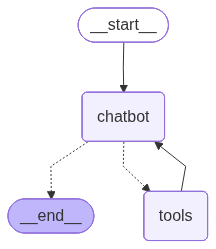

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [14]:
messages = {"messages": [{"role": "user", "content": "介绍一下LangGraph的create_react_agent这个api"}]}

out = graph.invoke(messages)

In [19]:
for item in out['messages']:
    item.pretty_print()

================================ Human Message =================================

介绍一下LangGraph的create_react_agent这个api
================================== Ai Message ==================================

我来为您搜索LangGraph的create_react_agent API的详细信息。
Tool Calls:
  tavily_search (call_00_XpLword4QzImBfC9emFpsFxu)
 Call ID: call_00_XpLword4QzImBfC9emFpsFxu
  Args:
    query: LangGraph create_react_agent API documentation
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph create_react_agent API documentation", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://langchain-ai.github.io/langgraph/agents/agents/", "title": "with a prebuilt agent - LangGraph quickstart - GitHub Pages", "content": "2. Create an agent¶\n\nTo create an agent, use `create_react_agent`:\n\n_API Reference: create\\_react\\_agent_\n\n```\nfrom langgraph.prebuilt import create_react_agent\

In [25]:
messages2 = {"messages": [{"role": "user", "content": "检索一下今天（2025/10/10）南宁的天气"}]}

out2 = graph.invoke(messages2)

In [26]:
for item in out2['messages']:
    item.pretty_print()

================================ Human Message =================================

检索一下今天（2025/10/10）南宁的天气
================================== Ai Message ==================================

我来帮您查询今天南宁的天气情况。
Tool Calls:
  tavily_search (call_00_S3nVJLgkxdyruU4qauAC2aAN)
 Call ID: call_00_S3nVJLgkxdyruU4qauAC2aAN
  Args:
    query: 南宁天气 2025年10月10日
    time_range: day
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "南宁天气 2025年10月10日", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.zgjia.com/report/guangxi20251010.html", "title": "2025年10月10日周五广西大部为多云天气最高温35℃ - 我的家天气网", "content": "广西壮族自治区主要城市天气情况：. 南宁市天气 多云东南风一二级 33~24°C. 北海市天气 多云东风三至四级 32~25°C. 百色市天气 晴转多云东南风一二级 34~23°C. 崇左市天气", "score": 0.923268, "raw_content": null}, {"url": "https://www.qweather.com/weather30d/nanning-101300101.html", "title": "南宁市未来30天天气预报", "content": "未来30天将有9天下雨，最高温33°（10月10日，10月11日），最